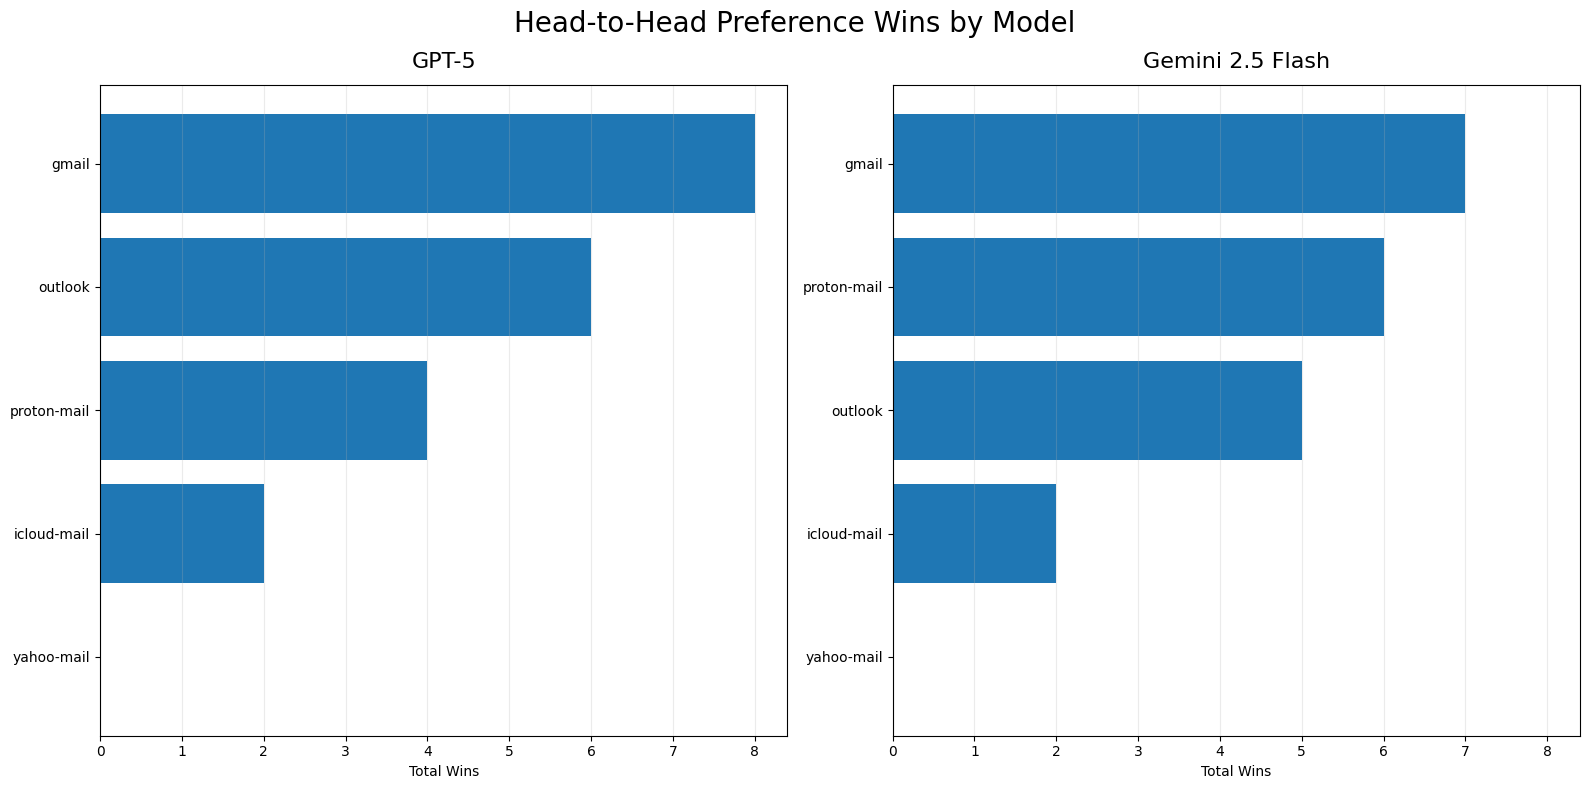

In [2]:
import json
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gemini.parquet"


def load_wins(path):
    df = pl.read_parquet(path)
    rows = []
    for r in df.to_dicts():
        payload = json.loads(r["serialised_result"])
        for rank in payload["ranking"]:
            rows.append(
                {
                    "entity": rank["entity_name"],
                    "wins": rank["wins"],
                }
            )
    return (
        pd.DataFrame(rows)
        .groupby("entity", as_index=False)["wins"]
        .sum()
        .sort_values("wins", ascending=True)
    )


gpt = load_wins(gpt_path)
gemini = load_wins(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["wins"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Total Wins")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(gemini["entity"], gemini["wins"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Total Wins")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Head-to-Head Preference Wins by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()